<a href="https://colab.research.google.com/github/VeenaShep07/My-Profile-and-Portfolio/blob/main/Cleaning_%26_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==== SETUP: install and import libraries ====
# Run this cell once whenever you (re)connect to the runtime.

# 1. Install any libraries
!pip install pandas matplotlib seaborn --quiet

# 2. Import all the core libraries you’ll use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Global display options (optional)
pd.set_option("display.max_rows", 10)
sns.set(style="whitegrid")

print("Setup complete")


Setup complete


In [ ]:
# Connect this notebook to your Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()           # you chose "student.csv or GDP nominal cpita file from choose files – below tab


Saving GDP (nominal) per Capita.csv to GDP (nominal) per Capita.csv


In [ ]:
full_path = '/content/student.csv'  # match the name shown after upload.

In [ ]:
df = pd.read_csv('/content/GDP (nominal) per Capita.csv')             # file that appears on the left
df.head()


,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [ ]:
print("Dataset loaded: Filename.csv")
print(f"Shape: {df.shape}")


Dataset loaded: Filename.csv
Shape: (223, 9)


In [ ]:
df['Country/Territory'] = df['Country/Territory'].str.strip()

In [ ]:
df.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [ ]:
df['Country/Territory'] = df['Country/Territory'].str.strip()

In [ ]:
df.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [ ]:
df['column'].str.strip():

SyntaxError: invalid syntax (1976891433.py, line 1)

In [ ]:
df['column'] = df['column'].astype(str).str.strip()

KeyError: 'column'

In [ ]:
df['Country/Territory'] = df['Country/Territory'].astype(str).str.strip()

In [ ]:
df.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [ ]:
pd.to_datetime(df['IMF_Year']):

SyntaxError: invalid syntax (2347006509.py, line 1)

In [ ]:
pd.to_datetime(df['IMF_Year'])

,IMF_Year
0,1970-01-01 00:00:00.000000000
1,1970-01-01 00:00:00.000000000
2,1970-01-01 00:00:00.000002023
3,1970-01-01 00:00:00.000002023
4,1970-01-01 00:00:00.000000000
...,...
218,1970-01-01 00:00:00.000002023
219,1970-01-01 00:00:00.000002023
220,1970-01-01 00:00:00.000002023
221,1970-01-01 00:00:00.000002020


In [ ]:
df.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,0,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
4,5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [ ]:
print(df[IMF_Year].head())

NameError: name 'IMF_Year' is not defined

In [ ]:
# c) Convert 'WorldBank_Estimate' to integer.
df['WorldBank_Estimate'] = pd.to_numeric(df['WorldBank_Estimate'], errors='coerce').fillna(0).astype(int)


In [ ]:
print(df.dtypes)

Unnamed: 0             int64
Country/Territory     object
UN_Region             object
IMF_Estimate           int64
IMF_Year               int64
WorldBank_Estimate     int64
WorldBank_Year         int64
UN_Estimate            int64
UN_Year               object
dtype: object


In [ ]:
col = 'IMF_Estimate'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]


In [ ]:
outliers.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
2,3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,6,Norway,Europe,101103,2023,89154,2021,89242,2021
6,7,Switzerland,Europe,98767,2023,91992,2021,93525,2021
7,8,Singapore,Asia,91100,2023,72794,2021,66822,2021


In [ ]:
df.shape

(223, 9)

In [ ]:

# 3. Print outliers shape
print("Outliers shape:", outliers.shape)

Outliers shape: (23, 9)


In [ ]:
# b) Convert 'IMF_Year' to datetime
df['IMF_Year'] = pd.to_datetime(df['IMF_Year'], format='%Y')

ValueError: time data "0" doesn't match format "%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df['IMF Year'] = pd.to_datetime(df['IMF Year'], format='%Y', errors='coerce')

KeyError: 'IMF Year'

In [ ]:
df['IMF_Year'] = pd.to_datetime(
    df['IMF_Year'],
    format='%Y',
    errors='coerce'
)

In [ ]:
df.head()

,Unnamed: 0,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
0,1,Monaco,Europe,0,NaT,234316,2021,234317,2021
1,2,Liechtenstein,Europe,0,NaT,157755,2020,169260,2021
2,3,Luxembourg,Europe,132372,2023-01-01,133590,2021,133745,2021
3,4,Ireland,Europe,114581,2023-01-01,100172,2021,101109,2021
4,5,Bermuda,Americas,0,NaT,114090,2021,112653,2021


In [ ]:
print(df['IMF_Year'].head())

0          NaT
1          NaT
2   2023-01-01
3   2023-01-01
4          NaT
Name: IMF_Year, dtype: datetime64[ns]


In [ ]:
print(df['IMF_Year'].dtype)

datetime64[ns]


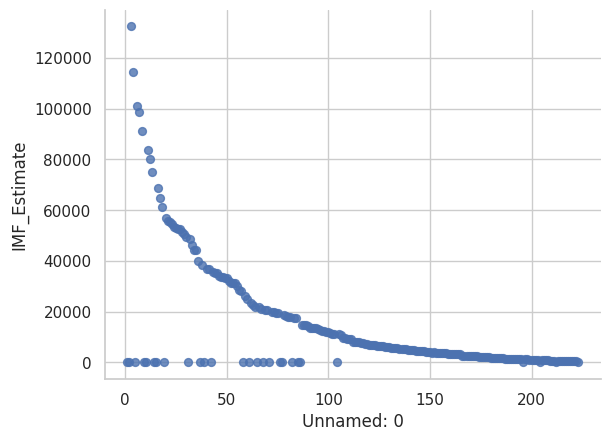

In [ ]:
df.plot(kind='scatter', x='Unnamed: 0', y='IMF_Estimate', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


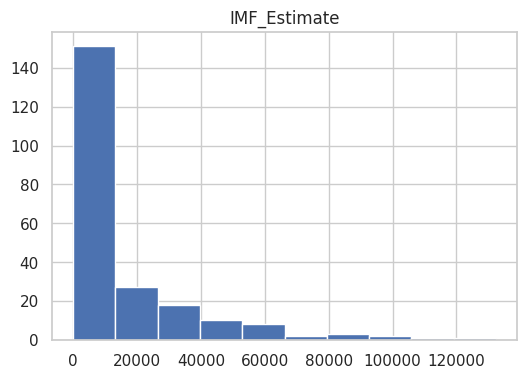

In [ ]:
df.hist(column='IMF_Estimate', figsize=(6, 4))
plt.show()


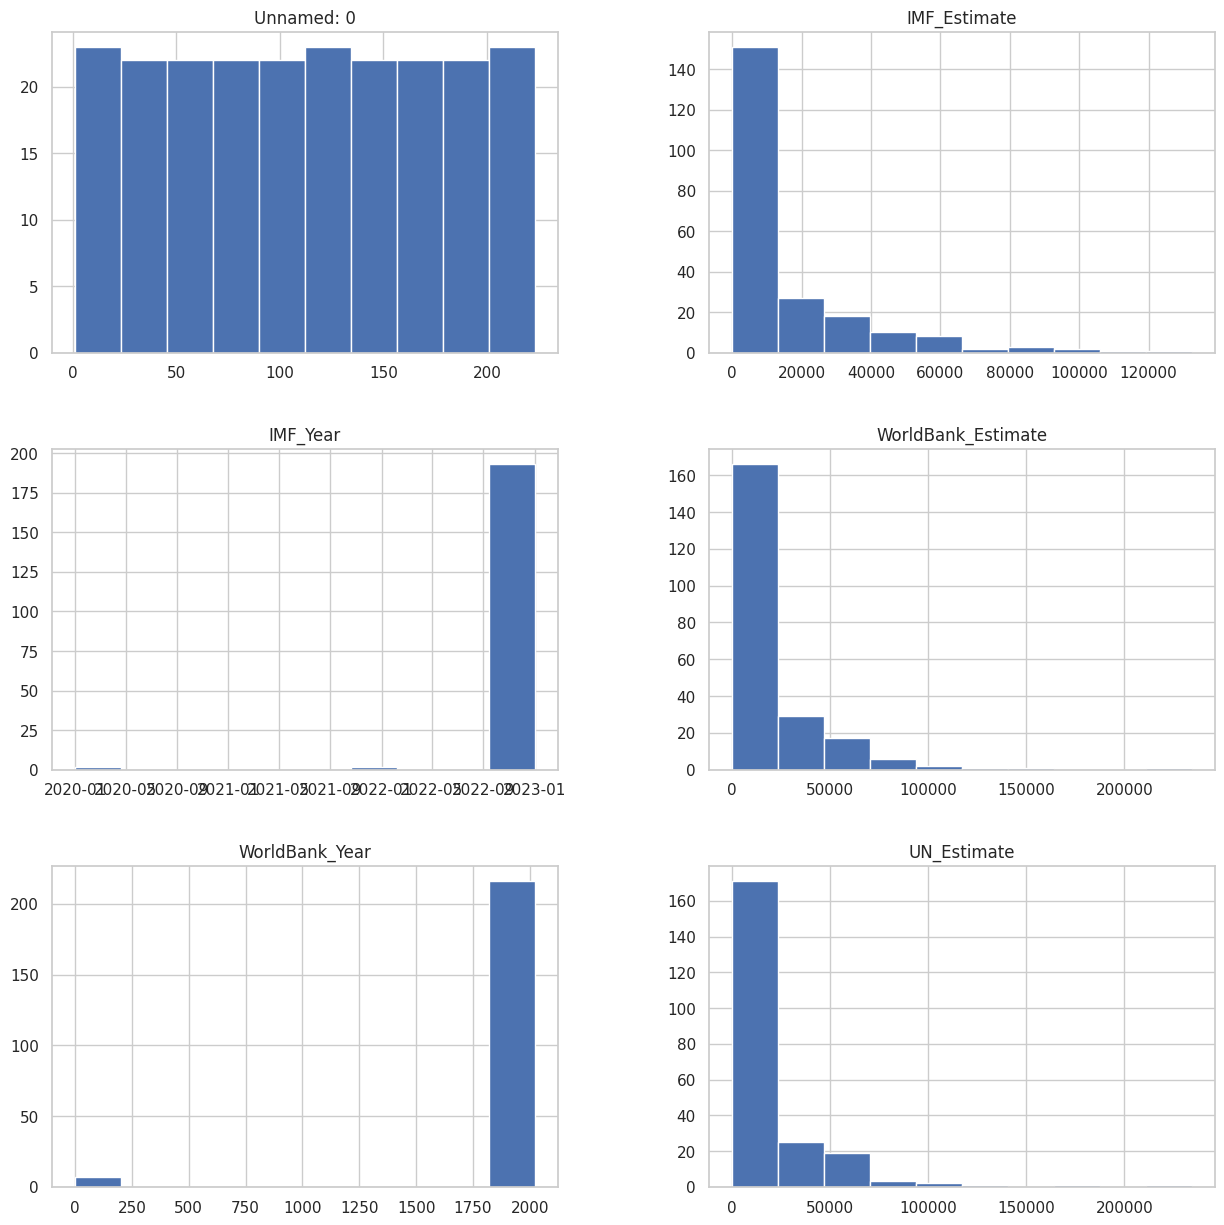

In [ ]:
df.hist(figsize=(15, 15))
plt.show()


In [ ]:
!pip install seaborn

In [ ]:
import seaborn as sns
#Import the seaborn module.


In [ ]:
# Select only the numerical features for correlation analysis
numerical_features = df.select_dtypes(include=['number'])


In [ ]:
# Calculate the correlation matrix
corr = numerical_features.corr()


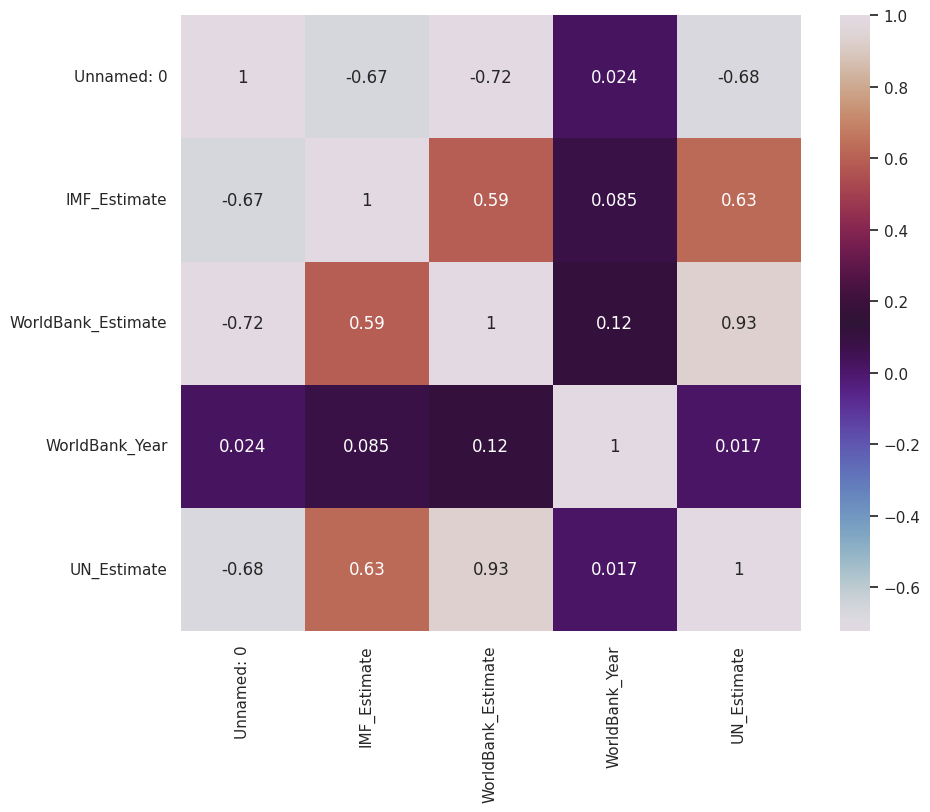

In [ ]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='twilight')
plt.show()


In [ ]:
print(plt.colormaps())      # list of all available cmap names

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

/tmp/ipykernel_8054/1567482934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="UN_Region", y="IMF_Estimate", data=df, errorbar=None, palette="bright6")


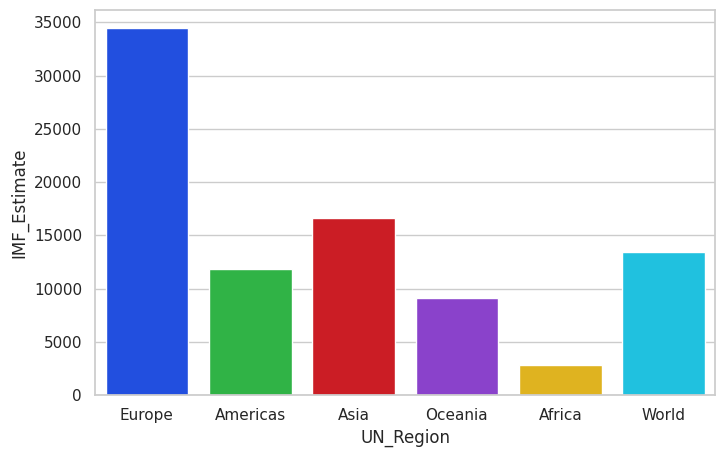

In [ ]:
fig = plt.figure(figsize=(8, 5)) #Now plt is defined and can be used.
sns.barplot(x="UN_Region", y="IMF_Estimate", data=df, errorbar=None, palette="bright6")
plt.show()


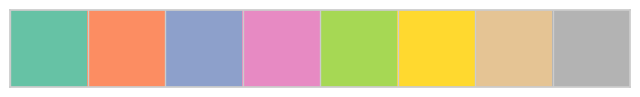

In [ ]:
sns.palplot(sns.color_palette("Set2")) # try "Set2", "Set3", "pastel", "bright", etc. plt.show()

In [ ]:
print(sns.palettes.SEABORN_PALETTES.keys())

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


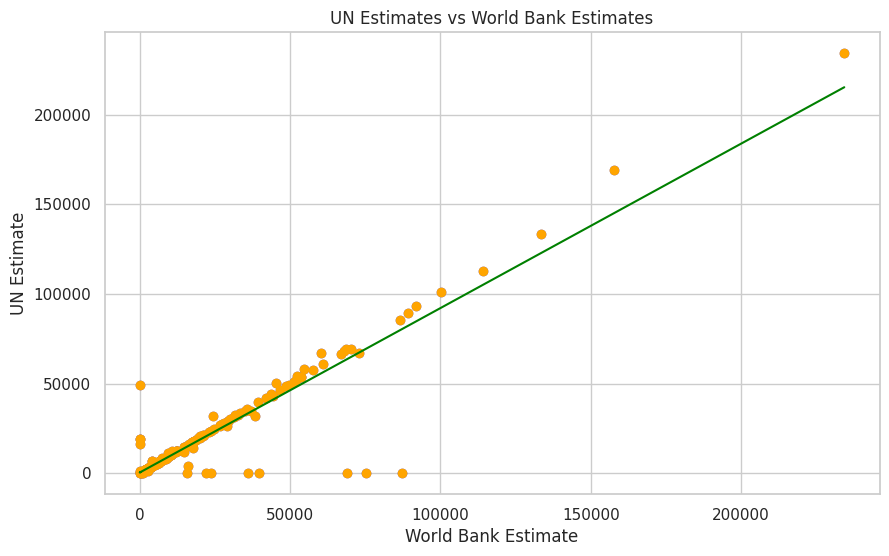

In [ ]:
#scatter plot

plt.figure(figsize=(10, 6))
plt.scatter(df['WorldBank_Estimate'], df['UN_Estimate'], color='blue', alpha=0.6)

plt.title('UN Estimates vs World Bank Estimates')
plt.xlabel('World Bank Estimate')
plt.ylabel('UN Estimate')

plt.grid(True)

import numpy as np

# Calculate the trend line and a colour:
m, b = np.polyfit(df['WorldBank_Estimate'], df['UN_Estimate'], 1)  # Linear fit
plt.plot(df['WorldBank_Estimate'], m * df['WorldBank_Estimate'] + b, color='green', linestyle='-')


#Then add this line of code to change the colour of dots
plt.scatter(df['WorldBank_Estimate'], df['UN_Estimate'], color='orange') # colour of dots


plt.show()




In [ ]:
from google.colab import files
uploaded = files.upload()

#Choose file > GDP nominal per capita.csv


Saving GDP (nominal) per Capita.csv to GDP (nominal) per Capita (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('GDP (nominal) per Capita.csv')


In [ ]:
from matplotlib import pyplot as plt

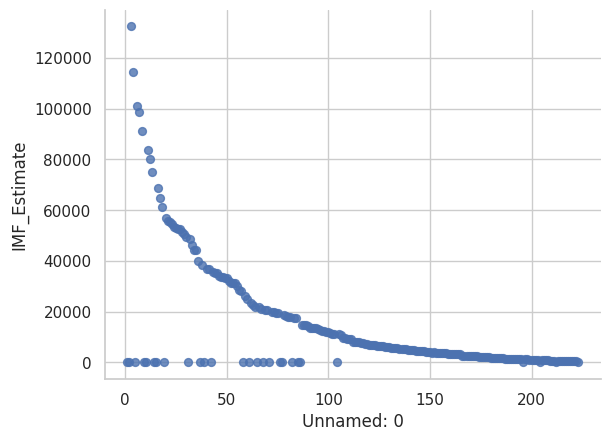

In [ ]:
df.plot(kind='scatter', x='Unnamed: 0', y='IMF_Estimate', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


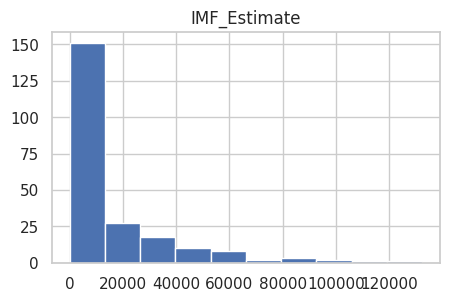

In [ ]:
df.hist(column='IMF_Estimate',figsize=(5,3))
plt.show()

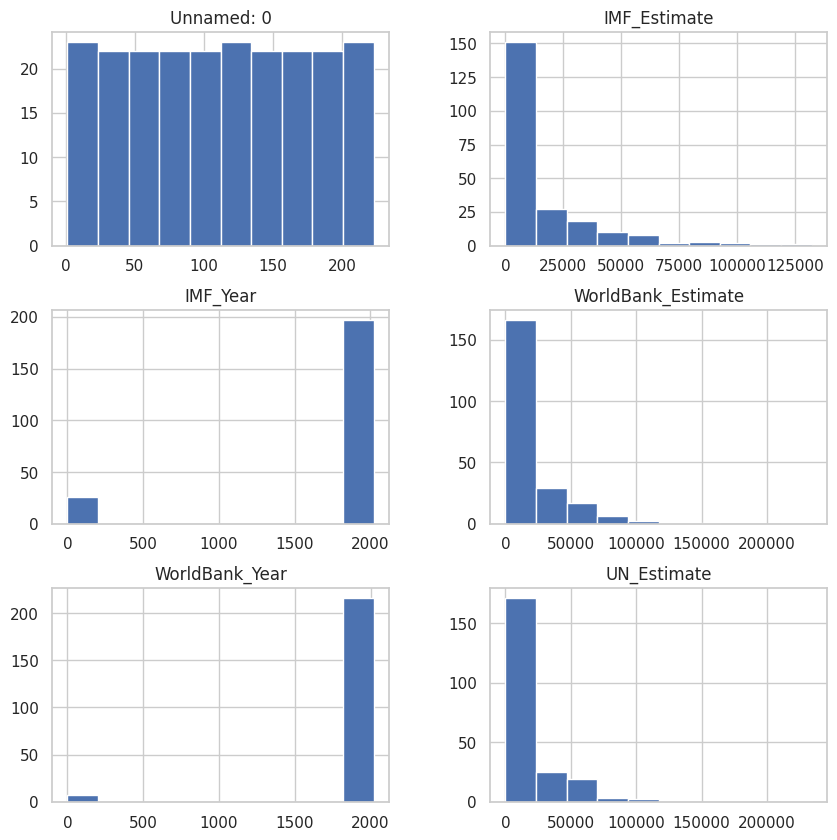

In [ ]:
df.hist(figsize=(10, 10))
plt.show()


In [ ]:
!pip install seaborn

In [ ]:
import seaborn as sns
#Import the seaborn module.


In [ ]:
# Select only the numerical features for correlation analysis
numerical_features = df.select_dtypes(include=['number'])


In [ ]:
# Calculate the correlation matrix
corr = numerical_features.corr()


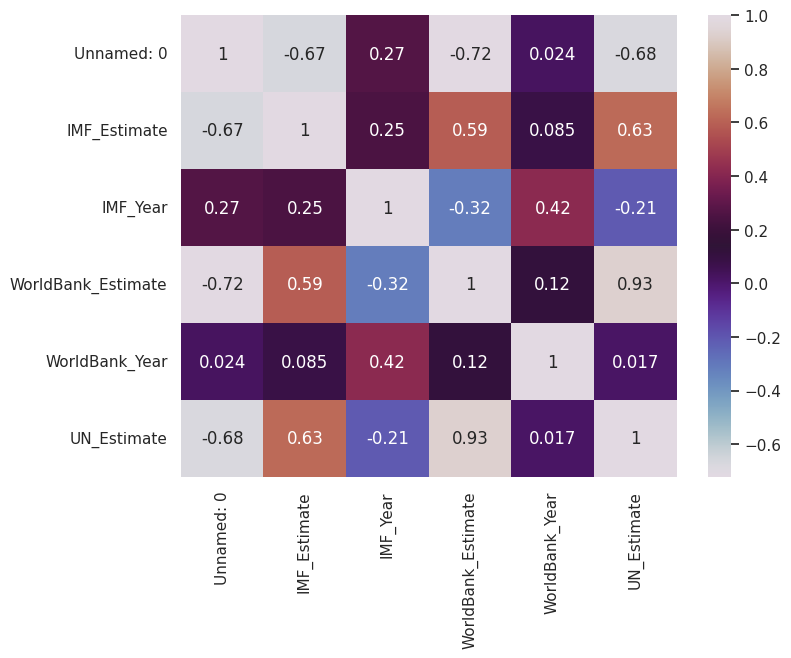

In [ ]:
#plot a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='twilight')
plt.show()

In [ ]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

/tmp/ipykernel_8054/3576313189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="UN_Region", y="IMF_Estimate", data=df, errorbar=None, palette="Set2")


<Figure size 800x500 with 0 Axes>

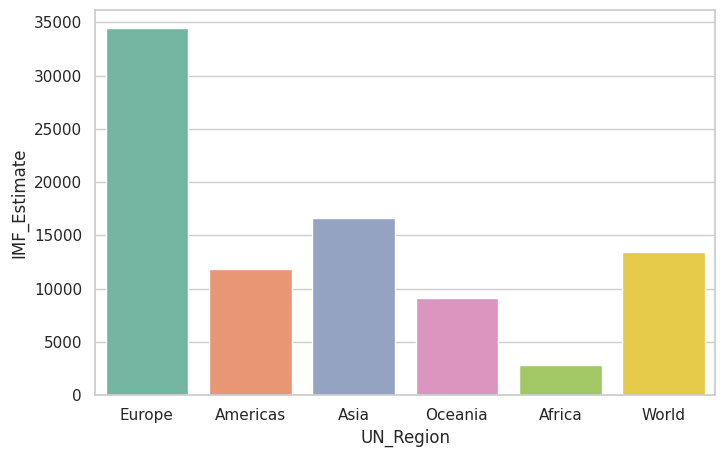

In [ ]:
fig = plt.figure(figsize=(8, 5)) #Now plt is defined and can be used.
fig = plt.figure(figsize=(8, 5))  #Now plt is defined and can be used.
sns.barplot(x="UN_Region", y="IMF_Estimate", data=df, errorbar=None, palette="Set2")
plt.show()





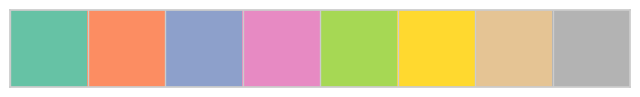

In [ ]:
sns.palplot(sns.color_palette("Set2")) # try "Set2", "Set3", "pastel", "bright", etc. plt.show()

In [ ]:
print(sns.palettes.SEABORN_PALETTES.keys()) #previously I gave you colour palette for Cmaps, this is colours for seaamp palette

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])


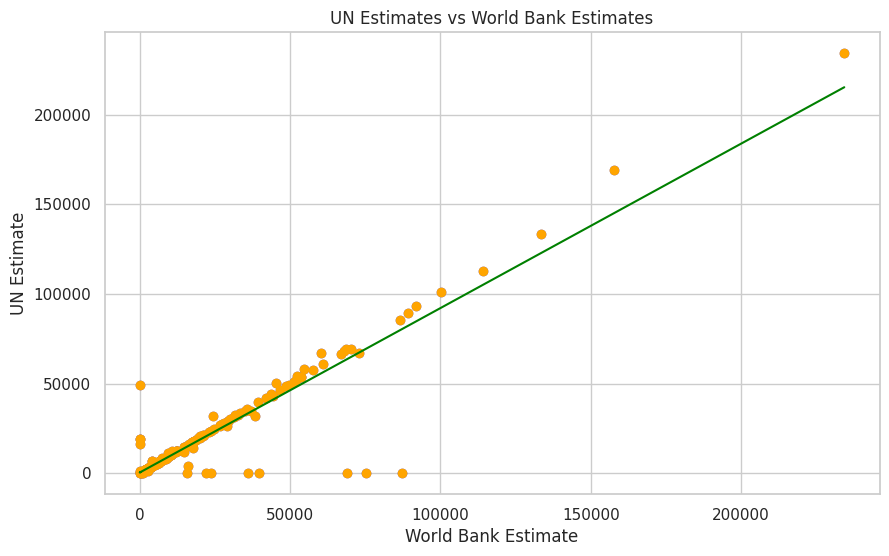

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['WorldBank_Estimate'], df['UN_Estimate'], color='blue', alpha=0.6)

plt.title('UN Estimates vs World Bank Estimates')
plt.xlabel('World Bank Estimate')
plt.ylabel('UN Estimate')

plt.grid(True)

import numpy as np

# Calculate the trend line and a colour:
m, b = np.polyfit(df['WorldBank_Estimate'], df['UN_Estimate'], 1)  # Linear fit
plt.plot(df['WorldBank_Estimate'], m * df['WorldBank_Estimate'] + b, color='green', linestyle='-')

#Then add this line of code to change the colour of dots
plt.scatter(df['WorldBank_Estimate'], df['UN_Estimate'], color='orange') # colour of dots



plt.show()




In [ ]:
from google.colab import files
uploaded = files.upload()

#Then choose Student.csv file


Saving student.csv to student.csv


In [ ]:
# Use the exact filename you have just uploaded
df = pd.read_csv('student.csv')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df.head()

,id,name,class,mark,gender
0,1,John Deo,Four,75,female
1,2,Max Ruin,Three,85,male
2,3,Arnold,Three,55,male
3,4,Krish Star,Four,60,female
4,5,John Mike,Four,60,female


/tmp/ipykernel_8054/752802950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='mark', data=df, palette='Set2')


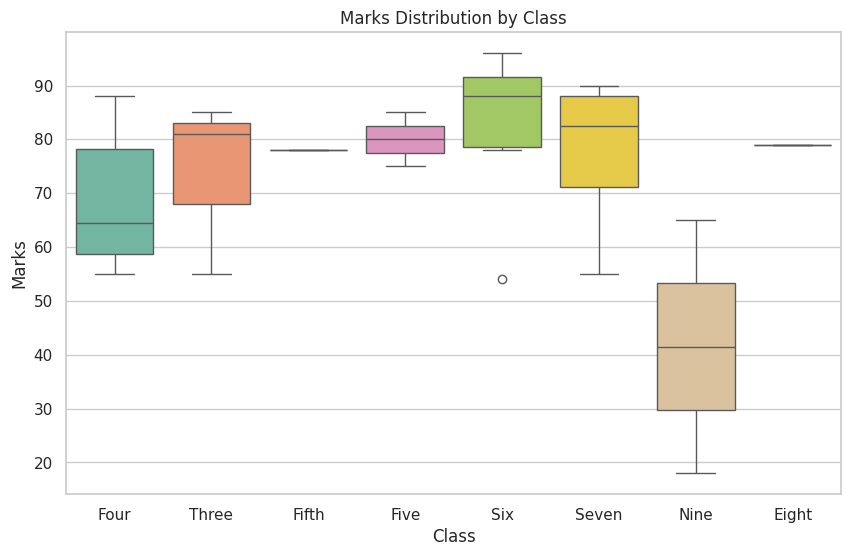

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='mark', data=df, palette='Set2')
plt.title('Marks Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Marks')
plt.show()


/tmp/ipykernel_8054/2543529193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='mark', data=avg_marks_gender, palette='pastel')  # Change 'deep' to your preferred palette


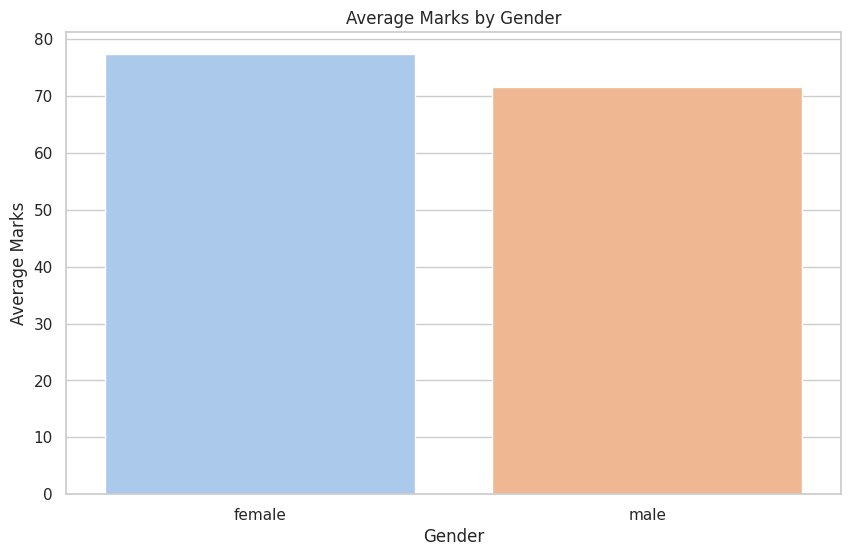

In [ ]:
plt.figure(figsize=(10, 6))
avg_marks_gender = df.groupby('gender')['mark'].mean().reset_index()
sns.barplot(x='gender', y='mark', data=avg_marks_gender, palette='pastel')  # Change 'deep' to your preferred palette
plt.title('Average Marks by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Marks')
plt.show()


In [ ]:
# See the built in Seaborn palette names
print(sns.palettes.SEABORN_PALETTES.keys())


dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])
